In [4]:
#导入必要库
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import sys
from pathlib import Path

In [6]:
project_root=Path.cwd().parent
sys.path.insert(0, str(project_root))
from utils.psf_utils import defocus_psf, gaussian_psf

In [7]:
#加载原图像并转化为灰度图
image_path = '../images/sample_image.jpg' 
image = Image.open(image_path).convert('L')  
image_array = np.array(image)
#加载输出高斯模糊图像并转化为灰度图
blurred_image_path = '../outputs/gaussian_blurred_image.jpg'
blurred_image = Image.open(blurred_image_path).convert('L')
blurred_image_array = np.array(blurred_image)
#加载离焦模糊图像并转化为灰度图
defocus_blurred_image_path = '../outputs/defocus_blurred_image.jpg'
defocus_blurred_image = Image.open(defocus_blurred_image_path).convert('L')
defocus_blurred_image_array = np.array(defocus_blurred_image)


In [11]:
#计算高斯模糊的MTF
def calculate_mtf(image_array):
  #高斯模糊核直接引用即可
    psf = gaussian_psf(size=21, sigma=3)
    otf = np.fft.fft2(psf, s=image_array.shape)
    #计算MTF
    mtf = np.abs(otf) / np.max(np.abs(otf))
    return mtf 
#计算离焦模糊的MTF
def calculate_defocus_mtf(image_array):
    psf = defocus_psf(size=21, radius=5)
    otf = np.fft.fft2(psf, s=image_array.shape)
    mtf = np.abs(otf) / np.max(np.abs(otf))
    return mtf

In [16]:
#定义radial_average函数计算径向平均
def radial_average(mtf):
  center = np.array(mtf.shape) // 2
  y, x = np.indices(mtf.shape)
  r = np.sqrt((x - center[1])**2 + (y - center[0])**2)
  r = r.astype(int)
  radial_sum = np.bincount(r.ravel(), mtf.ravel())
  radial_count = np.bincount(r.ravel())
  radial_profile = radial_sum / radial_count
  return radial_profile

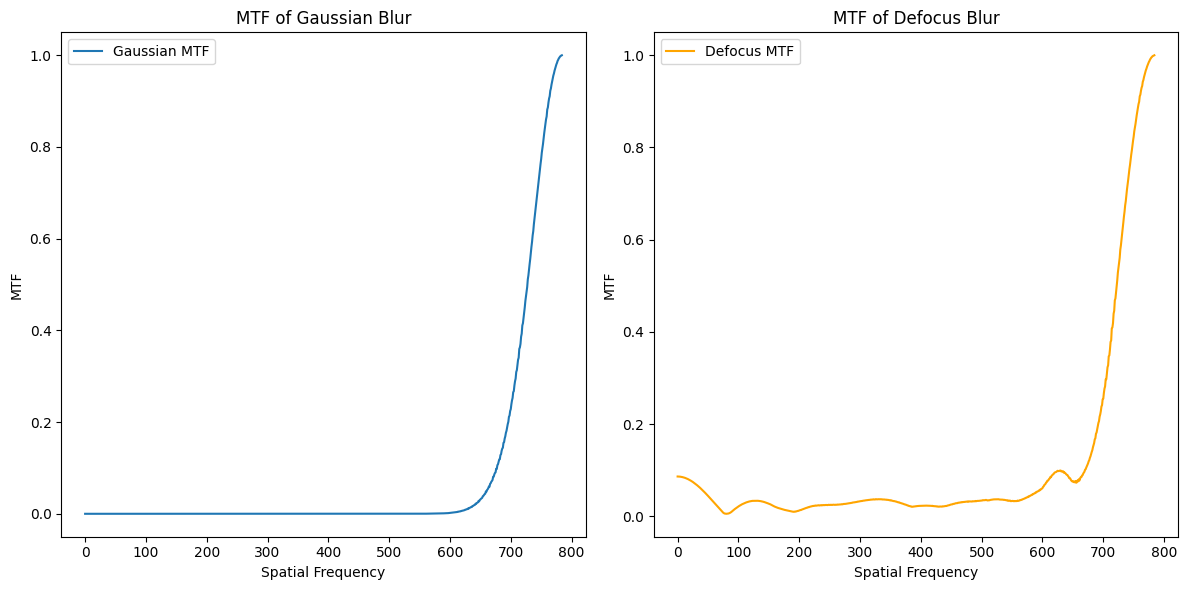

In [18]:
#展示MTF结果
gaussian_mtf = calculate_mtf(image_array)
#取径向平均值获得一维MTF曲线
gaussian_mtf_1d = radial_average(gaussian_mtf)
defocus_mtf = calculate_defocus_mtf(image_array)
#取径向平均值获得一维MTF曲线
defocus_mtf_1d = radial_average(defocus_mtf)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1) 
plt.plot(gaussian_mtf_1d, label='Gaussian MTF')
plt.title('MTF of Gaussian Blur')
plt.xlabel('Spatial Frequency')
plt.ylabel('MTF')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(defocus_mtf_1d, label='Defocus MTF', color='orange')
plt.title('MTF of Defocus Blur')
plt.xlabel('Spatial Frequency')
plt.ylabel('MTF')
plt.legend()
plt.tight_layout()
plt.show()
